---

# <center> ★ Machine Learning Project - Ad Budget Estimation ★
#### <center> ***Domain: Automotive***

---

<center><img src="https://raw.githubusercontent.com/Masterx-AI/Project_Auto_MPG_Prediction_/main/a.jpg" style="width: 600px;"/>

---

### Description:

The data is technical spec of cars. The dataset is downloaded from UCI Machine Learning Repository

"The data concerns city-cycle fuel consumption in miles per gallon,
to be predicted in terms of 3 multivalued discrete and 5 continuous
attributes." (Quinlan, 1993)
Number of Instances: 398
Number of Attributes: 9 including the class attribute

#### Acknowledgements
Dataset: UCI Machine Learning Repository<br>
Data link : https://archive.ics.uci.edu/ml/datasets/auto+mpg


### Objective:
- Understand the Dataset & cleanup (if required).
- Build Regression models to predict the sales w.r.t a single & multiple feature.
- Also evaluate the models & compare their respective scores like R2, RMSE, etc.

---

# <center> Stractegic Plan of Action:

**We aim to solve the problem statement by creating a plan of action, Here are some of the necessary steps:**
1. Data Exploration
2. Exploratory Data Analysis (EDA)
3. Data Pre-processing
4. Data Manipulation
5. Feature Selection/Extraction
6. Predictive Modelling
7. Project Outcomes & Conclusion

---

# <center>1. Data Exploration

In [1]:
#Importing the basic librarires

import math
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

#from brokenaxes import brokenaxes
from statsmodels.formula import api
from sklearn.feature_selection import RFE
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [10,6]

import warnings 
warnings.filterwarnings('ignore')

In [2]:
#Importing the dataset

df = pd.read_csv('../input/auto-mpg-dataset/auto-mpg.csv')

df.drop(['car name'], axis=1, inplace=True)
display(df.head())

target = 'mpg'
features = [i for i in df.columns if i not in [target]]

original_df = df.copy(deep=True)

print('\n\033[1mInference:\033[0m The Datset consists of {} features & {} samples.'.format(df.shape[1], df.shape[0]))

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin
0,18.0,8,307.0,130,3504,12.0,70,1
1,15.0,8,350.0,165,3693,11.5,70,1
2,18.0,8,318.0,150,3436,11.0,70,1
3,16.0,8,304.0,150,3433,12.0,70,1
4,17.0,8,302.0,140,3449,10.5,70,1



Inference: The Datset consists of 8 features & 398 samples.


In [3]:
#Checking the dtypes of all the columns

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    object 
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
dtypes: float64(3), int64(4), object(1)
memory usage: 25.0+ KB


In [4]:
#Checking number of unique rows in each feature

df.nunique().sort_values()

origin            3
cylinders         5
model year       13
displacement     82
horsepower       94
acceleration     95
mpg             129
weight          351
dtype: int64

In [5]:
#Checking number of unique rows in each feature

nu = df[features].nunique().sort_values()
nf = []; cf = []; nnf = 0; ncf = 0; #numerical & categorical features

for i in range(df[features].shape[1]):
    if nu.values[i]<=16:cf.append(nu.index[i])
    else: nf.append(nu.index[i])

print('\n\033[1mInference:\033[0m The Datset has {} numerical & {} categorical features.'.format(len(nf),len(cf)))


Inference: The Datset has 4 numerical & 3 categorical features.


In [6]:
#Checking the stats of all the columns

display(df.describe())

,mpg,cylinders,displacement,weight,acceleration,model year,origin
count,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,2970.424623,15.568090,76.010050,1.572864
std,7.815984,1.701004,104.269838,846.841774,2.757689,3.697627,0.802055
min,9.000000,3.000000,68.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.500000,4.000000,104.250000,2223.750000,13.825000,73.000000,1.000000
50%,23.000000,4.000000,148.500000,2803.500000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,262.000000,3608.000000,17.175000,79.000000,2.000000
max,46.600000,8.000000,455.000000,5140.000000,24.800000,82.000000,3.000000


**Inference:** The stats seem to be fine, let us do further analysis on the Dataset

---

# <center> 2. Exploratory Data Analysis (EDA)

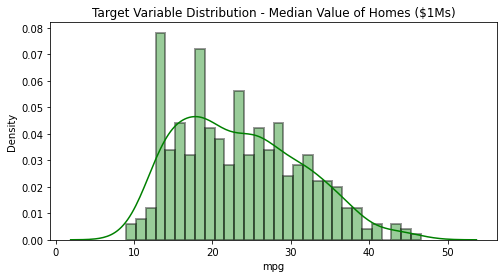

In [7]:
#Let us first analyze the distribution of the target variable

plt.figure(figsize=[8,4])
sns.distplot(df[target], color='g',hist_kws=dict(edgecolor="black", linewidth=2), bins=30)
plt.title('Target Variable Distribution - Median Value of Homes ($1Ms)')
plt.show()

**Inference:**The Target Variable seems to be be normally distributed, averaging around 20 units.

                               Visualising Categorical Features:                                


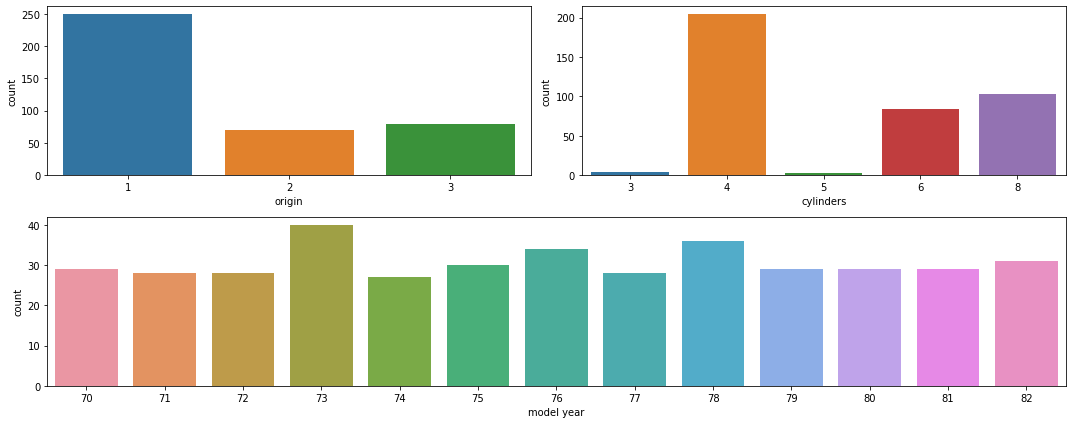

In [8]:
#Visualising the categorical features 

print('\033[1mVisualising Categorical Features:'.center(100))

n=2
plt.figure(figsize=[15,3*math.ceil(len(cf)/n)])

for i in range(len(cf)):
    if df[cf[i]].nunique()<=8:
        plt.subplot(math.ceil(len(cf)/n),n,i+1)
        sns.countplot(df[cf[i]])
    else:
        plt.subplot(2,1,2)
        sns.countplot(df[cf[i]])
        
plt.tight_layout()
plt.show()

**Inference:** There are no categorical features in the dataset.

                                                Numeric Features Distribution                                                 


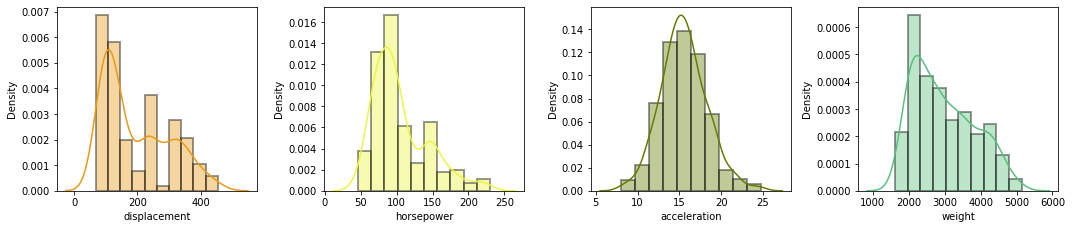

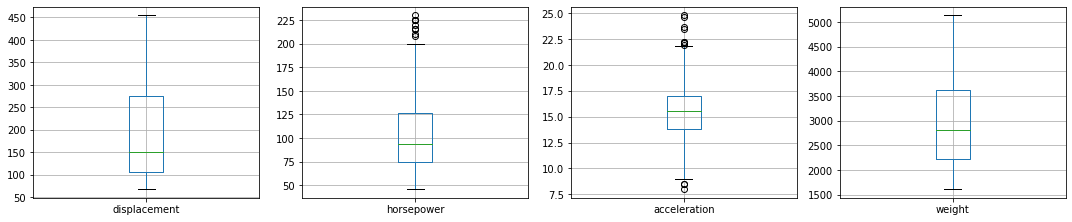

In [9]:
#Visualising the numeric features 

print('\033[1mNumeric Features Distribution'.center(130))

n=4
df = df[~df['horsepower'].isin(['?'])]
df.reset_index(drop=True, inplace=True)
df['horsepower']= df['horsepower'].astype(int)

clr=['r','g','b','g','b','r']

plt.figure(figsize=[15,6*math.ceil(len(nf)/n)])
for i in range(len(nf)):
    plt.subplot(math.ceil(len(nf)/3),n,i+1)
    sns.distplot(df[nf[i]],hist_kws=dict(edgecolor="black", linewidth=2), bins=10, color=list(np.random.randint([255,255,255])/255))
plt.tight_layout()
plt.show()

plt.figure(figsize=[15,6*math.ceil(len(nf)/n)])
for i in range(len(nf)):
    plt.subplot(math.ceil(len(nf)/3),n,i+1)
    df.boxplot(nf[i])
plt.tight_layout()
plt.show()

**Inference:** There seem to be some outliers. let us fix these in the upcoming section...

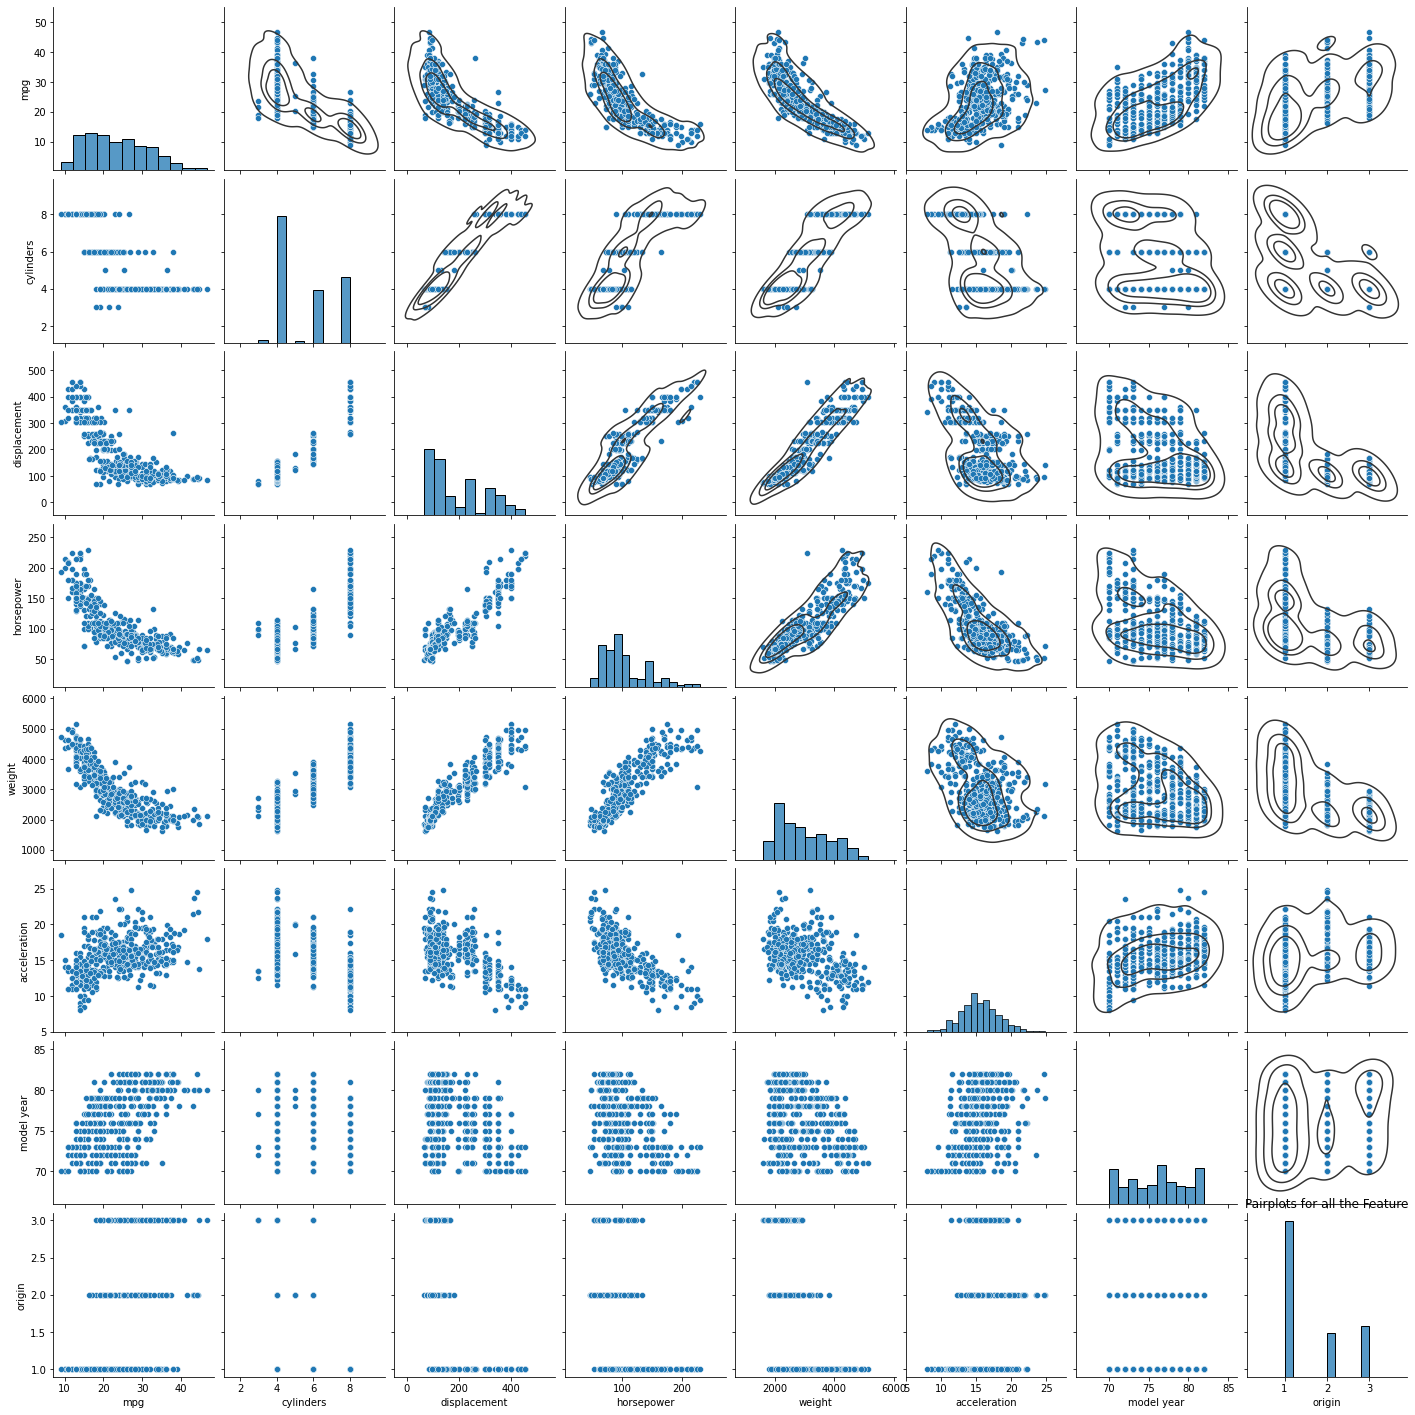

In [10]:
#Understanding the relationship between all the features

g = sns.pairplot(df)
plt.title('Pairplots for all the Feature')
g.map_upper(sns.kdeplot, levels=4, color=".2")
plt.show()

**Inference:** We can notice that some features have linear relationship, let us futher analyze the detect multicollinearity.

---

# <center> 3. Data Preprocessing

In [11]:
#Removal of any Duplicate rows (if any)

counter = 0
rs,cs = original_df.shape

df.drop_duplicates(inplace=True)

if df.shape==(rs,cs):
    print('\n\033[1mInference:\033[0m The dataset doesn\'t have any duplicates')
else:
    print(f'\n\033[1mInference:\033[0m Number of duplicates dropped/fixed ---> {rs-df.shape[0]}')


Inference: Number of duplicates dropped/fixed ---> 6


In [12]:
#Check for empty elements

nvc = pd.DataFrame(df.isnull().sum().sort_values(), columns=['Total Null Values'])
nvc['Percentage'] = round(nvc['Total Null Values']/df.shape[0],3)*100
print(nvc)

              Total Null Values  Percentage
mpg                           0         0.0
cylinders                     0         0.0
displacement                  0         0.0
horsepower                    0         0.0
weight                        0         0.0
acceleration                  0         0.0
model year                    0         0.0
origin                        0         0.0


**Inference:** The datset doesn't have any inconsistant values.

In [13]:
#Converting categorical Columns to Numeric

df3 = df.copy()

ecc = nvc[nvc['Percentage']!=0].index.values
fcc = [i for i in cf if i not in ecc]
#One-Hot Binay Encoding
oh=True
dm=True
for i in fcc:
    #print(i)
    if df3[i].nunique()==2:
        if oh==True: print("\033[1mOne-Hot Encoding on features:\033[0m")
        print(i);oh=False
        df3[i]=pd.get_dummies(df3[i], drop_first=True, prefix=str(i))
    if (df3[i].nunique()>2 and df3[i].nunique()<17):
        if dm==True: print("\n\033[1mDummy Encoding on features:\033[0m")
        print(i);dm=False
        df3 = pd.concat([df3.drop([i], axis=1), pd.DataFrame(pd.get_dummies(df3[i], drop_first=True, prefix=str(i)))],axis=1)
        
df3.shape


Dummy Encoding on features:
origin
cylinders
model year


(392, 23)

In [14]:
# for x in [i for i in ecc if i in cf]:
#     a = df3[x]
#     b=[]; c=[]

#     df4 = df3.copy()
#     df4.drop(ecc, axis=1, inplace=True)
#     df4

#     for i,e in enumerate(a):
#         if e!=e:
#             b.append(i)
#         else:
#             c.append(i)

#     RF = RandomForestClassifier()
#     RF.fit(df4.loc[c],a[c])
#     d = RF.predict(df4.loc[b])

#     f=0
#     for i,e in enumerate(df3[x]):
#         if e!=e:
#             df3.loc[i,x] = d[f]
#             f+=1
# df1 = df3.copy()
# df1

In [15]:
# #Converting categorical Columns to Numeric

# df3 = df.copy()

# gcc = nvc[nvc['Percentage']!=0].index.values
# hcc = [i for i in cf if i not in gcc]

# #One-Hot Binay Encoding
# oh=True
# dm=True
# for i in hcc:
#     #print(i)
#     if df3[i].nunique()==2:
#         if oh==True: print("\033[1mOne-Hot Encoding on features:\033[0m")
#         print(i);oh=False
#         df3[i]=pd.get_dummies(df3[i], drop_first=True, prefix=str(i))
#     if (df3[i].nunique()>2 and df3[i].nunique()<17):
#         if dm==True: print("\n\033[1mDummy Encoding on features:\033[0m")
#         print(i);dm=False
#         df3 = pd.concat([df3.drop([i], axis=1), pd.DataFrame(pd.get_dummies(df3[i], drop_first=True, prefix=str(i)))],axis=1)
# df3.shape

In [16]:
# for x in gcc:
#     a = df3[x]
#     b=[]; c=[]

#     df4 = df3.copy()
#     df4.drop([x], axis=1, inplace=True)
    
#     for i,e in enumerate(a):
#         if e!=e:
#             b.append(i)
#         else:
#             c.append(i)
        
#     LR = LinearRegression()
#     LR.fit(df4.loc[c],a[c])
#     d = LR.predict(df4.loc[b])
        
#     f=0
#     for i,e in enumerate(df3[x]):
#         if e!=e:
#             df3.loc[i,x] = d[f]
#             f+=1
# df3

In [17]:
#Removal of outlier:

df1 = df3.copy()

#features1 = [i for i in features if i not in ['CHAS','RAD']]
features1 = nf

for i in features1:
    Q1 = df1[i].quantile(0.25)
    Q3 = df1[i].quantile(0.75)
    IQR = Q3 - Q1
    df1 = df1[df1[i] <= (Q3+(1.5*IQR))]
    df1 = df1[df1[i] >= (Q1-(1.5*IQR))]
    df1 = df1.reset_index(drop=True)
display(df1.head())
print('\n\033[1mInference:\033[0m\nBefore removal of outliers, The dataset had {} samples.'.format(df3.shape[0]))
print('After removal of outliers, The dataset now has {} samples.'.format(df1.shape[0]))

,mpg,displacement,horsepower,weight,acceleration,origin_2,origin_3,cylinders_4,cylinders_5,cylinders_6,...,model year_73,model year_74,model year_75,model year_76,model year_77,model year_78,model year_79,model year_80,model year_81,model year_82
0,18.0,307.0,130,3504,12.0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,15.0,350.0,165,3693,11.5,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,18.0,318.0,150,3436,11.0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,16.0,304.0,150,3433,12.0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,17.0,302.0,140,3449,10.5,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0



Inference:
Before removal of outliers, The dataset had 392 samples.
After removal of outliers, The dataset now has 373 samples.


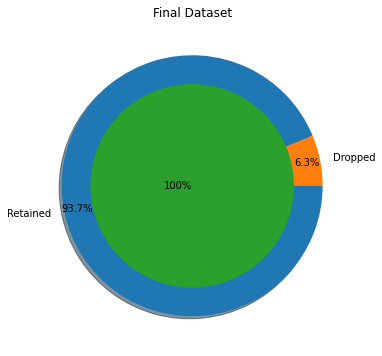


Inference: After the cleanup process, 25 samples were dropped, while retaining 6.28% of the data.


In [18]:
#Final Dataset size after performing Preprocessing

df = df1.copy()
df.columns=[i.replace('-','_') for i in df.columns]

plt.title('Final Dataset')
plt.pie([df.shape[0], original_df.shape[0]-df.shape[0]], radius = 1, labels=['Retained','Dropped'], counterclock=False, 
        autopct='%1.1f%%', pctdistance=0.9, explode=[0,0], shadow=True)
plt.pie([df.shape[0]], labels=['100%'], labeldistance=-0, radius=0.78)
plt.show()

print(f'\n\033[1mInference:\033[0m After the cleanup process, {original_df.shape[0]-df.shape[0]} samples were dropped, \
while retaining {round(100 - (df.shape[0]*100/(original_df.shape[0])),2)}% of the data.')

---

# <center> 4. Data Manipulation

In [19]:
#Splitting the data intro training & testing sets

m=[]
for i in df.columns.values:
    m.append(i.replace(' ','_'))
    
df.columns = m
X = df.drop([target],axis=1)
Y = df[target]
Train_X, Test_X, Train_Y, Test_Y = train_test_split(X, Y, train_size=0.8, test_size=0.2, random_state=100)
Train_X.reset_index(drop=True,inplace=True)

print('Original set  ---> ',X.shape,Y.shape,'\nTraining set  ---> ',Train_X.shape,Train_Y.shape,'\nTesting set   ---> ', Test_X.shape,'', Test_Y.shape)

Original set  --->  (373, 22) (373,) 
Training set  --->  (298, 22) (298,) 
Testing set   --->  (75, 22)  (75,)


In [20]:
#Feature Scaling (Standardization)

std = StandardScaler()

print('\033[1mStandardardization on Training set'.center(120))
Train_X_std = std.fit_transform(Train_X)
Train_X_std = pd.DataFrame(Train_X_std, columns=X.columns)
display(Train_X_std.describe())

print('\n','\033[1mStandardardization on Testing set'.center(120))
Test_X_std = std.transform(Test_X)
Test_X_std = pd.DataFrame(Test_X_std, columns=X.columns)
display(Test_X_std.describe())

                                         Standardardization on Training set                                         


,displacement,horsepower,weight,acceleration,origin_2,origin_3,cylinders_4,cylinders_5,cylinders_6,cylinders_8,...,model_year_73,model_year_74,model_year_75,model_year_76,model_year_77,model_year_78,model_year_79,model_year_80,model_year_81,model_year_82
count,2.980000e+02,2.980000e+02,2.980000e+02,2.980000e+02,2.980000e+02,2.980000e+02,2.980000e+02,2.980000e+02,2.980000e+02,2.980000e+02,...,2.980000e+02,2.980000e+02,2.980000e+02,2.980000e+02,2.980000e+02,2.980000e+02,2.980000e+02,2.980000e+02,2.980000e+02,2.980000e+02
mean,-7.451161e-17,1.758474e-16,2.313586e-16,6.044755e-16,8.475696e-17,9.015905e-17,-1.676511e-17,7.451161e-19,9.686510e-18,-8.419812e-17,...,4.507953e-17,-8.382556e-17,3.390278e-17,5.960929e-18,6.221720e-17,-9.686510e-17,-1.359837e-16,-8.196277e-17,7.041347e-17,-6.221720e-17
std,1.001682e+00,1.001682e+00,1.001682e+00,1.001682e+00,1.001682e+00,1.001682e+00,1.001682e+00,1.001682e+00,1.001682e+00,1.001682e+00,...,1.001682e+00,1.001682e+00,1.001682e+00,1.001682e+00,1.001682e+00,1.001682e+00,1.001682e+00,1.001682e+00,1.001682e+00,1.001682e+00
min,-1.193437e+00,-1.661251e+00,-1.579042e+00,-2.122077e+00,-4.757494e-01,-5.229764e-01,-1.048137e+00,-8.219949e-02,-5.281761e-01,-5.644325e-01,...,-3.407416e-01,-2.823299e-01,-2.891995e-01,-3.156438e-01,-2.891995e-01,-3.026138e-01,-2.753403e-01,-2.753403e-01,-2.891995e-01,-2.753403e-01
25%,-8.415279e-01,-7.759633e-01,-8.610395e-01,-6.720466e-01,-4.757494e-01,-5.229764e-01,-1.048137e+00,-8.219949e-02,-5.281761e-01,-5.644325e-01,...,-3.407416e-01,-2.823299e-01,-2.891995e-01,-3.156438e-01,-2.891995e-01,-3.026138e-01,-2.753403e-01,-2.753403e-01,-2.891995e-01,-2.753403e-01
50%,-4.845917e-01,-2.152813e-01,-2.629963e-01,-5.060508e-02,-4.757494e-01,-5.229764e-01,9.540736e-01,-8.219949e-02,-5.281761e-01,-5.644325e-01,...,-3.407416e-01,-2.823299e-01,-2.891995e-01,-3.156438e-01,-2.891995e-01,-3.026138e-01,-2.753403e-01,-2.753403e-01,-2.891995e-01,-2.753403e-01
75%,6.968168e-01,5.224582e-01,7.010703e-01,6.019085e-01,-4.757494e-01,-5.229764e-01,9.540736e-01,-8.219949e-02,-5.281761e-01,-5.644325e-01,...,-3.407416e-01,-2.823299e-01,-2.891995e-01,-3.156438e-01,-2.891995e-01,-3.026138e-01,-2.753403e-01,-2.753403e-01,-2.891995e-01,-2.753403e-01
max,2.416143e+00,2.883225e+00,2.548743e+00,2.600879e+00,2.101947e+00,1.912132e+00,9.540736e-01,1.216553e+01,1.893308e+00,1.771691e+00,...,2.934775e+00,3.541956e+00,3.457820e+00,3.168128e+00,3.457820e+00,3.304542e+00,3.631870e+00,3.631870e+00,3.457820e+00,3.631870e+00



                                          Standardardization on Testing set                                          


,displacement,horsepower,weight,acceleration,origin_2,origin_3,cylinders_4,cylinders_5,cylinders_6,cylinders_8,...,model_year_73,model_year_74,model_year_75,model_year_76,model_year_77,model_year_78,model_year_79,model_year_80,model_year_81,model_year_82
count,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,...,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000,75.000000
mean,0.002919,-0.066553,-0.100686,-0.121311,-0.166426,-0.035955,-0.060380,0.081104,0.052980,-0.003763,...,-0.078700,-0.078368,0.060522,-0.083392,-0.039398,0.226436,0.037236,-0.014860,-0.039398,0.141429
std,0.958443,0.958450,0.830193,1.010223,0.843293,0.980603,1.007757,1.414245,1.041139,1.004438,...,0.894609,0.865094,1.097344,0.874857,0.940965,1.284709,1.067138,0.981193,0.940965,1.214235
min,-1.213546,-1.572722,-1.366041,-2.536371,-0.475749,-0.522976,-1.048137,-0.082199,-0.528176,-0.564433,...,-0.340742,-0.282330,-0.289200,-0.315644,-0.289200,-0.302614,-0.275340,-0.275340,-0.289200,-0.275340
25%,-0.841528,-0.790718,-0.909023,-0.713476,-0.475749,-0.522976,-1.048137,-0.082199,-0.528176,-0.564433,...,-0.340742,-0.282330,-0.289200,-0.315644,-0.289200,-0.302614,-0.275340,-0.275340,-0.289200,-0.275340
50%,-0.379019,-0.362829,-0.148888,-0.050605,-0.475749,-0.522976,-1.048137,-0.082199,-0.528176,-0.564433,...,-0.340742,-0.282330,-0.289200,-0.315644,-0.289200,-0.302614,-0.275340,-0.275340,-0.289200,-0.275340
75%,0.656599,0.345401,0.597203,0.529407,-0.475749,-0.522976,0.954074,-0.082199,-0.528176,-0.564433,...,-0.340742,-0.282330,-0.289200,-0.315644,-0.289200,-0.302614,-0.275340,-0.275340,-0.289200,-0.275340
max,2.416143,2.824206,1.613642,1.855149,2.101947,1.912132,0.954074,12.165525,1.893308,1.771691,...,2.934775,3.541956,3.457820,3.168128,3.457820,3.304542,3.631870,3.631870,3.457820,3.631870


---

# <center> 5. Feature Selection/Extraction

                                       Correlation Matrix                                       


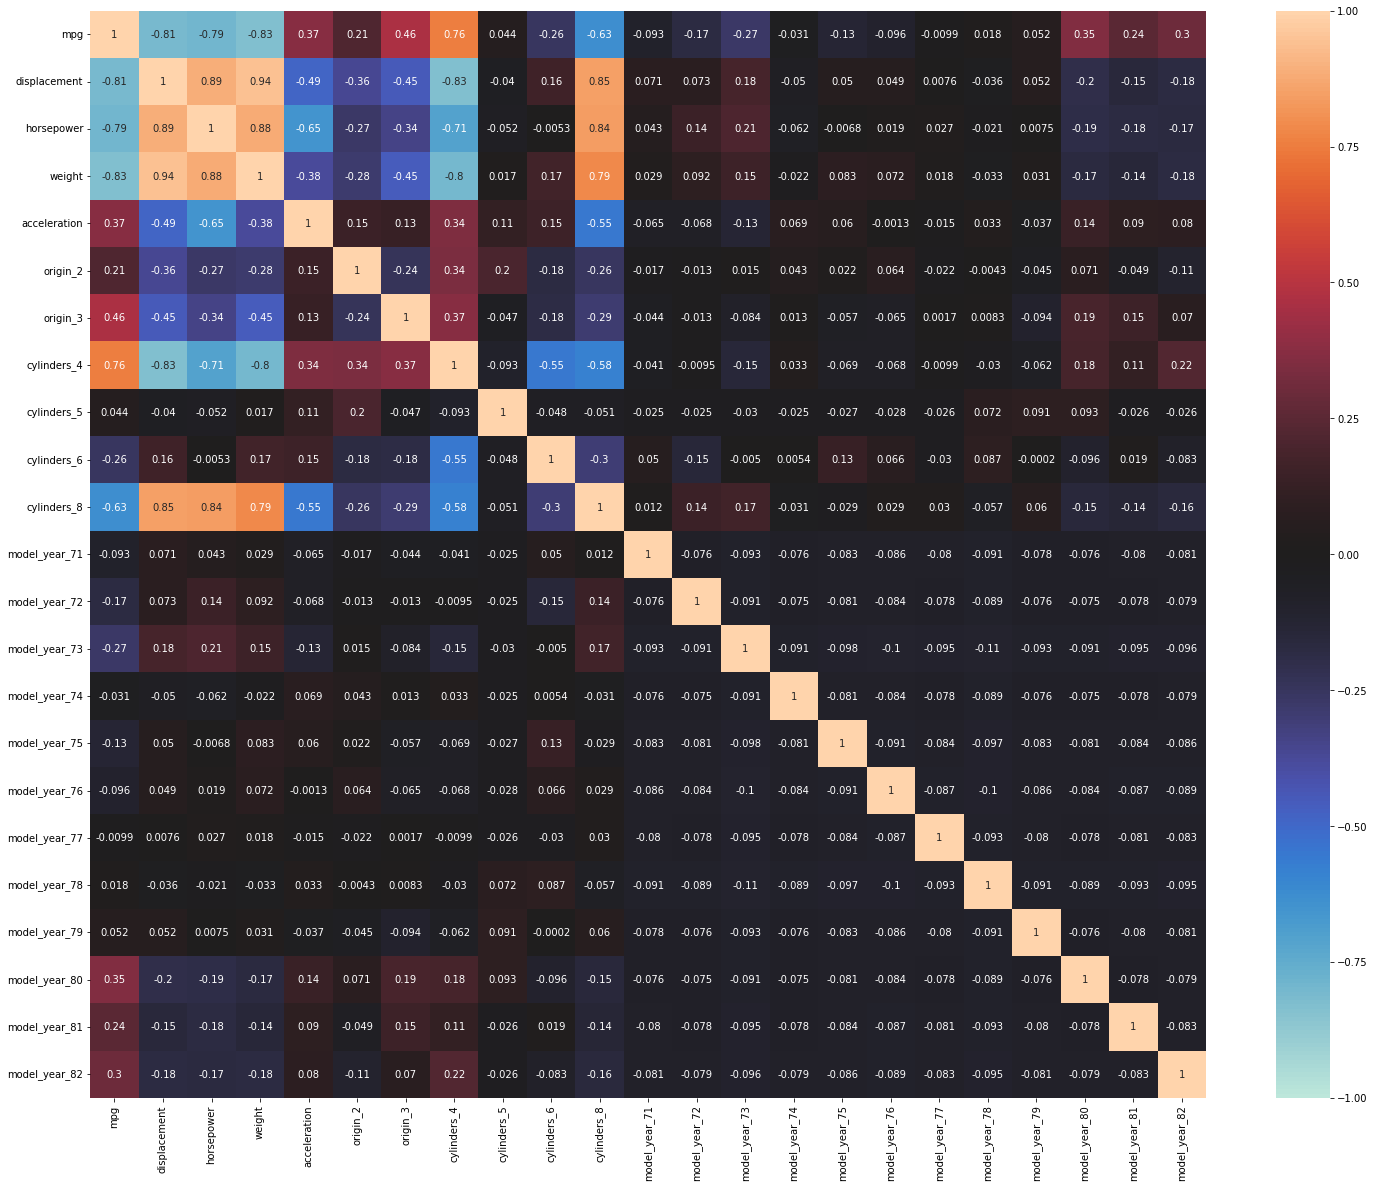

In [21]:
#Checking the correlation

print('\033[1mCorrelation Matrix'.center(100))
plt.figure(figsize=[25,20])
sns.heatmap(df.corr(), annot=True, vmin=-1, vmax=1, center=0) #cmap='BuGn'
plt.show()

**Inference:** There seems to be strong multi-correlation between the features. Let us try to fix these...

In [22]:
#Testing a Linear Regression model with statsmodels

Train_xy = pd.concat([Train_X_std,Train_Y.reset_index(drop=True)],axis=1)
a = Train_xy.columns.values

API = api.ols(formula='{} ~ {}'.format(target,' + '.join(i for i in Train_X.columns)), data=Train_xy).fit()
#print(API.conf_int())
#print(API.pvalues)
API.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    mpg   R-squared:                       0.871
Model:                            OLS   Adj. R-squared:                  0.861
Method:                 Least Squares   F-statistic:                     84.53
Date:                Sat, 25 Dec 2021   Prob (F-statistic):          1.05e-108
Time:                        16:08:28   Log-Likelihood:                -726.34
No. Observations:                 298   AIC:                             1499.
Df Residuals:                     275   BIC:                             1584.
Df Model:                          22                                         
Covariance Type:            nonrobust                                         
=================================================================================
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept        23.5379      0.167    140.972      0.000      23.209      23.867
displacement      0.3739      0.900      0.416      0.678      -1.398       2.146
horsepower       -1.6099      0.594     -2.710      0.007      -2.779      -0.440
weight           -4.2347      0.729     -5.812      0.000      -5.669      -2.800
acceleration     -0.2032      0.281     -0.723      0.470      -0.757       0.350
origin_2          0.4622      0.241      1.920      0.056      -0.012       0.936
origin_3          0.8241      0.242      3.411      0.001       0.348       1.300
cylinders_4       3.5204      0.910      3.869      0.000       1.729       5.311
cylinders_5       0.8287      0.235      3.525      0.000       0.366       1.292
cylinders_6       2.1244      0.846      2.512      0.013       0.459       3.789
cylinders_8       3.4088      1.046      3.259      0.001       1.349       5.468
model_year_71     0.3186      0.260      1.224      0.222      -0.194       0.831
model_year_72    -0.0083      0.255     -0.033      0.974      -0.509       0.493
model_year_73    -0.1306      0.277     -0.471      0.638      -0.677       0.416
model_year_74     0.3833      0.260      1.477      0.141      -0.128       0.894
model_year_75     0.2529      0.268      0.944      0.346      -0.274       0.780
model_year_76     0.4447      0.271      1.641      0.102      -0.089       0.978
model_year_77     0.8663      0.258      3.359      0.001       0.359       1.374
model_year_78     0.8827      0.262      3.371      0.001       0.367       1.398
model_year_79     1.1685      0.255      4.582      0.000       0.666       1.671
model_year_80     2.3185      0.264      8.793      0.000       1.799       2.838
model_year_81     1.7093      0.270      6.336      0.000       1.178       2.240
model_year_82     2.0095      0.267      7.533      0.000       1.484       2.535
==============================================================================
Omnibus:                       34.262   Durbin-Watson:                   2.141
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               70.652
Skew:                           0.605   Prob(JB):                     4.55e-16
Kurtosis:                       5.056   Cond. No.                         22.3
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

 ---

**Approach:** 
We can fix these multicollinearity with two techniques:
1. Manual Method - Variance Inflation Factor (VIF)
2. Automatic Method - Recursive Feature Elimination (RFE)
3. Feature Elmination using PCA Decomposition

## 5a. Manual Method - VIF

Dropped Features -->  ['cylinders_8', 'displacement', 'horsepower', 'cylinders_4', 'model_year_73', 'weight', 'model_year_81', 'origin_2', 'model_year_80', 'model_year_75', 'cylinders_6', 'model_year_76', 'model_year_79', 'acceleration', 'model_year_71', 'model_year_72', 'model_year_74', 'model_year_77', 'model_year_78']


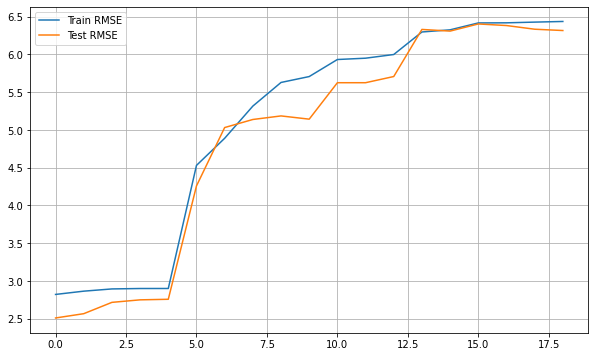

In [23]:
from sklearn.preprocessing import PolynomialFeatures
Trr=[]; Tss=[]; n=3
order=['ord-'+str(i) for i in range(2,n)]
#Trd = pd.DataFrame(np.zeros((10,n-2)), columns=order)
#Tsd = pd.DataFrame(np.zeros((10,n-2)), columns=order)

DROP=[];b=[]

for i in range(len(Train_X_std.columns)):
    vif = pd.DataFrame()
    X = Train_X_std.drop(DROP,axis=1)
    vif['Features'] = X.columns
    vif['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    vif['VIF'] = round(vif['VIF'], 2)
    vif = vif.sort_values(by = "VIF", ascending = False)
    vif.reset_index(drop=True, inplace=True)
    if vif.loc[0][1]>1:
        DROP.append(vif.loc[0][0])
        LR = LinearRegression()
        LR.fit(Train_X_std.drop(DROP,axis=1), Train_Y)

        pred1 = LR.predict(Train_X_std.drop(DROP,axis=1))
        pred2 = LR.predict(Test_X_std.drop(DROP,axis=1))
        
        Trr.append(np.sqrt(mean_squared_error(Train_Y, pred1)))
        Tss.append(np.sqrt(mean_squared_error(Test_Y, pred2)))

        #Trd.loc[i,'ord-'+str(k)] = round(np.sqrt(mean_squared_error(Train_Y, pred1)),2)
        #Tsd.loc[i,'ord-'+str(k)] = round(np.sqrt(mean_squared_error(Test_Y, pred2)),2)
        
print('Dropped Features --> ',DROP)
#plt.plot(b)
#plt.show()
#print(API.summary())

# plt.figure(figsize=[20,4])
# plt.subplot(1,3,1)
# sns.heatmap(Trd.loc[:6], cmap='BuGn', annot=True, vmin=0, vmax=Trd.max().max())
# plt.title('Train RMSE')
# plt.subplot(1,3,2)
# sns.heatmap(Tsd.loc[:6], cmap='BuGn', annot=True, vmin=0, vmax=Trd.max().max()+10)
# plt.title('Test RMSE')
# plt.subplot(1,3,3)
# sns.heatmap((Trd+Tsd).loc[:6], cmap='BuGn', annot=True, vmin=0, vmax=Trd.max().max()+25)
# plt.title('Total RMSE')
# plt.show()

plt.plot(Trr, label='Train RMSE')
plt.plot(Tss, label='Test RMSE')
#plt.ylim([19.75,20.75])
plt.legend()
plt.grid()
plt.show()

## 5b. Automatic Method - RFE

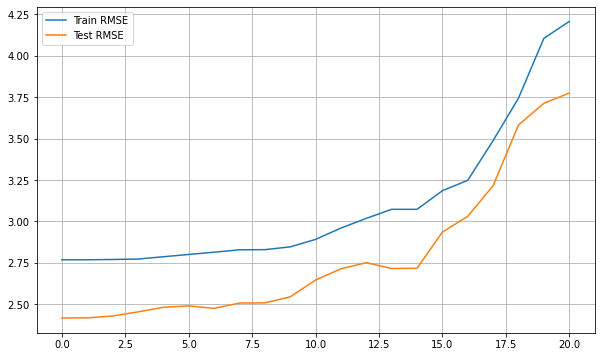

In [24]:
from sklearn.preprocessing import PolynomialFeatures
Trr=[]; Tss=[]; n=3
order=['ord-'+str(i) for i in range(2,n)]
Trd = pd.DataFrame(np.zeros((10,n-2)), columns=order)
Tsd = pd.DataFrame(np.zeros((10,n-2)), columns=order)

m=df.shape[1]-2
for i in range(m):
    lm = LinearRegression()
    rfe = RFE(lm,n_features_to_select=Train_X_std.shape[1]-i)             # running RFE
    rfe = rfe.fit(Train_X_std, Train_Y)

    LR = LinearRegression()
    LR.fit(Train_X_std.loc[:,rfe.support_], Train_Y)

    pred1 = LR.predict(Train_X_std.loc[:,rfe.support_])
    pred2 = LR.predict(Test_X_std.loc[:,rfe.support_])

    Trr.append(np.sqrt(mean_squared_error(Train_Y, pred1)))
    Tss.append(np.sqrt(mean_squared_error(Test_Y, pred2)))

# plt.figure(figsize=[20,4])
# plt.subplot(1,3,1)
# sns.heatmap(Trd.loc[:6], cmap='BuGn', annot=True, vmin=0, vmax=Trd.max().max())
# plt.title('Train RMSE')
# plt.subplot(1,3,2)
# sns.heatmap(Tsd.loc[:6], cmap='BuGn', annot=True, vmin=0, vmax=Trd.max().max()+10)
# plt.title('Test RMSE')
# plt.subplot(1,3,3)
# sns.heatmap((Trd+Tsd).loc[:6], cmap='BuGn', annot=True, vmin=0, vmax=Trd.max().max()+25)
# plt.title('Total RMSE')
# plt.show()

plt.plot(Trr, label='Train RMSE')
plt.plot(Tss, label='Test RMSE')
#plt.ylim([19.75,20.75])
plt.legend()
plt.grid()
plt.show()

## 5c. Feature Elmination using PCA Decomposition

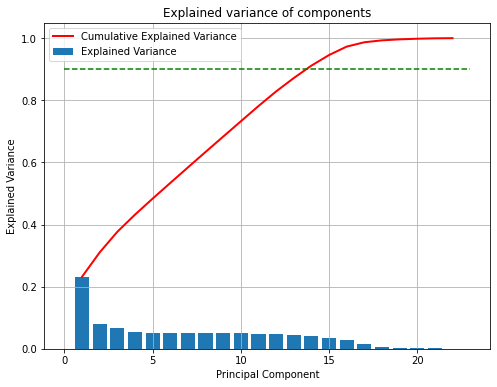

In [25]:
from sklearn.decomposition import PCA

pca = PCA().fit(Train_X_std)

fig, ax = plt.subplots(figsize=(8,6))
x_values = range(1, pca.n_components_+1)
ax.bar(x_values, pca.explained_variance_ratio_, lw=2, label='Explained Variance')
ax.plot(x_values, np.cumsum(pca.explained_variance_ratio_), lw=2, label='Cumulative Explained Variance', color='red')
plt.plot([0,pca.n_components_+1],[0.9,0.9],'g--')
ax.set_title('Explained variance of components')
ax.set_xlabel('Principal Component')
ax.set_ylabel('Explained Variance')
plt.legend()
plt.grid()
plt.show()

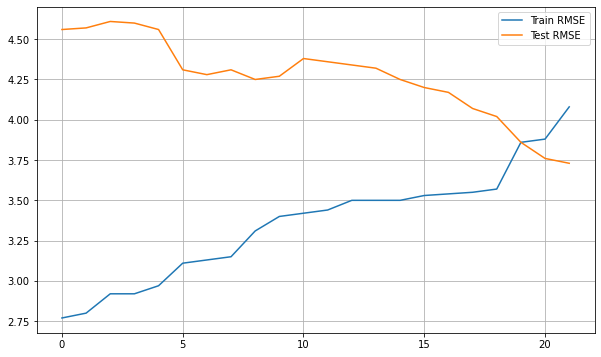

In [26]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import PolynomialFeatures
Trr=[]; Tss=[]; n=3
order=['ord-'+str(i) for i in range(2,n)]
Trd = pd.DataFrame(np.zeros((10,n-2)), columns=order)
Tsd = pd.DataFrame(np.zeros((10,n-2)), columns=order)
m=df.shape[1]-1

for i in range(m):
    pca = PCA(n_components=Train_X_std.shape[1]-i)
    Train_X_std_pca = pca.fit_transform(Train_X_std)
    Test_X_std_pca = pca.fit_transform(Test_X_std)
    
    LR = LinearRegression()
    LR.fit(Train_X_std_pca, Train_Y)

    pred1 = LR.predict(Train_X_std_pca)
    pred2 = LR.predict(Test_X_std_pca)

    Trr.append(round(np.sqrt(mean_squared_error(Train_Y, pred1)),2))
    Tss.append(round(np.sqrt(mean_squared_error(Test_Y, pred2)),2))

# plt.figure(figsize=[20,4.5])
# plt.subplot(1,3,1)
# sns.heatmap(Trd.loc[:6], cmap='BuGn', annot=True, vmin=0, vmax=Trd.max().max())
# plt.title('Train RMSE')
# plt.subplot(1,3,2)
# sns.heatmap(Tsd.loc[:6], cmap='BuGn', annot=True, vmin=0, vmax=Trd.max().max()+10)
# plt.title('Test RMSE')
# plt.subplot(1,3,3)
# sns.heatmap((Trd+Tsd).loc[:6], cmap='BuGn', annot=True, vmin=0, vmax=Trd.max().max()+25)
# plt.title('Total RMSE')
# plt.show()

plt.plot(Trr, label='Train RMSE')
plt.plot(Tss, label='Test RMSE')
#plt.ylim([19.5,20.75])
plt.legend()
plt.grid()
plt.show()

#### Inference:
It can be seen that the performance of the modelsis quiet comparable unpon dropping features using VIF, RFE & PCA Techniques. Comparing the RMSE plots, the optimal values were found for dropping most  features using manual RFE Technique. But let us skip these for now, as the advanced ML Algorithms take care of multicollinearity.

In [27]:
# #Shortlisting the selected Features (with RFE)

# lm = LinearRegression()
# rfe = RFE(lm,n_features_to_select=Train_X_std.shape[1]-8)             # running RFE
# rfe = rfe.fit(Train_X_std, Train_Y)

# LR = LinearRegression()
# LR.fit(Train_X_std.loc[:,rfe.support_], Train_Y)

# #print(Train_X_std.loc[:,rfe.support_].columns)

# pred1 = LR.predict(Train_X_std.loc[:,rfe.support_])
# pred2 = LR.predict(Test_X_std.loc[:,rfe.support_])

# print(np.sqrt(mean_squared_error(Train_Y, pred1)))
# print(np.sqrt(mean_squared_error(Test_Y, pred2)))

# Train_X_std = Train_X_std.loc[:,rfe.support_]
# Test_X_std = Test_X_std.loc[:,rfe.support_]

---

# <center> 6. Predictive Modelling

In [28]:
#Let us first define a function to evaluate our models

Model_Evaluation_Comparison_Matrix = pd.DataFrame(np.zeros([5,8]), columns=['Train-R2','Test-R2','Train-RSS','Test-RSS',
                                                                            'Train-MSE','Test-MSE','Train-RMSE','Test-RMSE'])
rc=np.random.choice(Train_X_std.loc[:,Train_X_std.nunique()>=50].columns.values,2,replace=False)
def Evaluate(n, pred1,pred2):
    #Plotting predicted predicteds alongside the actual datapoints 
    plt.figure(figsize=[15,6])
    for e,i in enumerate(rc):
        plt.subplot(2,3,e+1)
        plt.scatter(y=Train_Y, x=Train_X_std[i], label='Actual')
        plt.scatter(y=pred1, x=Train_X_std[i], label='Prediction')
        plt.legend()
    plt.show()

    #Evaluating the Multiple Linear Regression Model

    print('\n\n{}Training Set Metrics{}'.format('-'*20, '-'*20))
    print('\nR2-Score on Training set --->',round(r2_score(Train_Y, pred1),20))
    print('Residual Sum of Squares (RSS) on Training set  --->',round(np.sum(np.square(Train_Y-pred1)),20))
    print('Mean Squared Error (MSE) on Training set       --->',round(mean_squared_error(Train_Y, pred1),20))
    print('Root Mean Squared Error (RMSE) on Training set --->',round(np.sqrt(mean_squared_error(Train_Y, pred1)),20))

    print('\n{}Testing Set Metrics{}'.format('-'*20, '-'*20))
    print('\nR2-Score on Testing set --->',round(r2_score(Test_Y, pred2),20))
    print('Residual Sum of Squares (RSS) on Training set  --->',round(np.sum(np.square(Test_Y-pred2)),20))
    print('Mean Squared Error (MSE) on Training set       --->',round(mean_squared_error(Test_Y, pred2),20))
    print('Root Mean Squared Error (RMSE) on Training set --->',round(np.sqrt(mean_squared_error(Test_Y, pred2)),20))
    print('\n{}Residual Plots{}'.format('-'*20, '-'*20))
    
    Model_Evaluation_Comparison_Matrix.loc[n,'Train-R2']  = round(r2_score(Train_Y, pred1),20)
    Model_Evaluation_Comparison_Matrix.loc[n,'Test-R2']   = round(r2_score(Test_Y, pred2),20)
    Model_Evaluation_Comparison_Matrix.loc[n,'Train-RSS'] = round(np.sum(np.square(Train_Y-pred1)),20)
    Model_Evaluation_Comparison_Matrix.loc[n,'Test-RSS']  = round(np.sum(np.square(Test_Y-pred2)),20)
    Model_Evaluation_Comparison_Matrix.loc[n,'Train-MSE'] = round(mean_squared_error(Train_Y, pred1),20)
    Model_Evaluation_Comparison_Matrix.loc[n,'Test-MSE']  = round(mean_squared_error(Test_Y, pred2),20)
    Model_Evaluation_Comparison_Matrix.loc[n,'Train-RMSE']= round(np.sqrt(mean_squared_error(Train_Y, pred1)),20)
    Model_Evaluation_Comparison_Matrix.loc[n,'Test-RMSE'] = round(np.sqrt(mean_squared_error(Test_Y, pred2)),20)

    # Plotting y_test and y_pred to understand the spread.
    plt.figure(figsize=[15,4])

    plt.subplot(1,2,1)
    sns.distplot((Train_Y - pred1))
    plt.title('Error Terms')          
    plt.xlabel('Errors') 

    plt.subplot(1,2,2)
    plt.scatter(Train_Y,pred1)
    plt.plot([Train_Y.min(),Train_Y.max()],[Train_Y.min(),Train_Y.max()], 'r--')
    plt.title('Test vs Prediction')         
    plt.xlabel('y_test')                       
    plt.ylabel('y_pred')                       
    plt.show()

---

## Objective: 
Let us now try building multiple regression models & compare their evaluation metrics to choose the best fit model both training and testing sets...

## 6a. Multiple Linear Regression(MLR)

<img src="mr.png" style="width: 600px;float: left;"/>

<<<----------------------------------- Evaluating Multiple Linear Regression Model ----------------------------------->>>

The Coeffecient of the Regresion Model was found to be  [ 0.37392838 -1.60991106 -4.23465249 -0.20323733  0.46219093  0.82410016
  3.52035285  0.82870138  2.12435476  3.40883424  0.31857547 -0.00832717
 -0.1305993   0.38329303  0.25287433  0.44466142  0.86632505  0.88266555
  1.16851361  2.31850714  1.70934819  2.0094862 ]
The Intercept of the Regresion Model was found to be  23.537919463087253


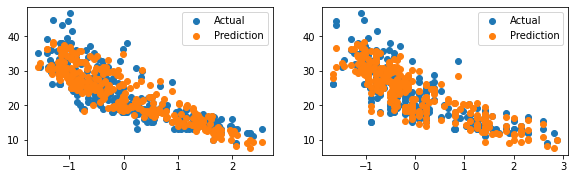



--------------------Training Set Metrics--------------------

R2-Score on Training set ---> 0.8711787959958208
Residual Sum of Squares (RSS) on Training set  ---> 2284.6494003909393
Mean Squared Error (MSE) on Training set       ---> 7.666608726144092
Root Mean Squared Error (RMSE) on Training set ---> 2.7688641581240656

--------------------Testing Set Metrics--------------------

R2-Score on Testing set ---> 0.8871356166042397
Residual Sum of Squares (RSS) on Training set  ---> 438.32538636033337
Mean Squared Error (MSE) on Training set       ---> 5.844338484804444
Root Mean Squared Error (RMSE) on Training set ---> 2.4175066669617364

--------------------Residual Plots--------------------


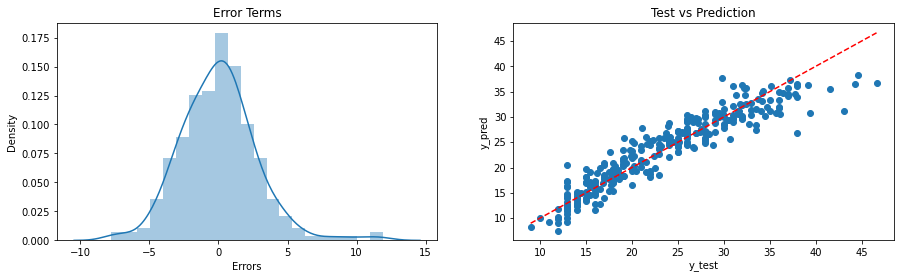

In [29]:
#Linear Regression

MLR = LinearRegression().fit(Train_X_std,Train_Y)
pred1 = MLR.predict(Train_X_std)
pred2 = MLR.predict(Test_X_std)

print('{}{}\033[1m Evaluating Multiple Linear Regression Model \033[0m{}{}\n'.format('<'*3,'-'*35 ,'-'*35,'>'*3))
print('The Coeffecient of the Regresion Model was found to be ',MLR.coef_)
print('The Intercept of the Regresion Model was found to be ',MLR.intercept_)

Evaluate(0, pred1, pred2)

---

## 6b. Ridge Regression Model

<img src="ridge.png" style="width: 500px;float: left;"/>

<<<----------------------------------- Evaluating Ridge Regression Model ----------------------------------->>>

The Coeffecient of the Regresion Model was found to be  [ 0.37392838 -1.60991106 -4.23465249 -0.20323733  0.46219093  0.82410016
  3.52035285  0.82870138  2.12435476  3.40883424  0.31857547 -0.00832717
 -0.1305993   0.38329303  0.25287433  0.44466142  0.86632505  0.88266555
  1.16851361  2.31850714  1.70934819  2.0094862 ]
The Intercept of the Regresion Model was found to be  23.537919463087253


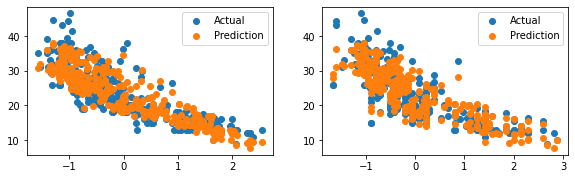



--------------------Training Set Metrics--------------------

R2-Score on Training set ---> 0.8708526075227881
Residual Sum of Squares (RSS) on Training set  ---> 2290.4343665002825
Mean Squared Error (MSE) on Training set       ---> 7.686021364094908
Root Mean Squared Error (RMSE) on Training set ---> 2.772367465559879

--------------------Testing Set Metrics--------------------

R2-Score on Testing set ---> 0.8877140594716572
Residual Sum of Squares (RSS) on Training set  ---> 436.0789186464295
Mean Squared Error (MSE) on Training set       ---> 5.8143855819523935
Root Mean Squared Error (RMSE) on Training set ---> 2.411303710019207

--------------------Residual Plots--------------------


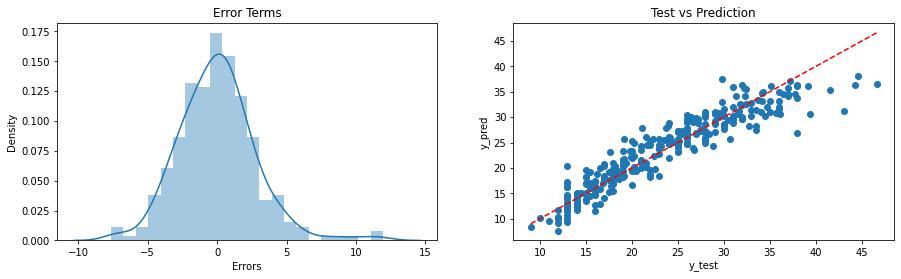

In [30]:
#Creating a Ridge Regression model

RLR = Ridge().fit(Train_X_std,Train_Y)
pred1 = RLR.predict(Train_X_std)
pred2 = RLR.predict(Test_X_std)

print('{}{}\033[1m Evaluating Ridge Regression Model \033[0m{}{}\n'.format('<'*3,'-'*35 ,'-'*35,'>'*3))
print('The Coeffecient of the Regresion Model was found to be ',MLR.coef_)
print('The Intercept of the Regresion Model was found to be ',MLR.intercept_)

Evaluate(1, pred1, pred2)

---

## 6c. Lasso Regression Model

<img src="lasso.png" style="width: 500px;float: left;"/>

<<<----------------------------------- Evaluating Lasso Regression Model ----------------------------------->>>

The Coeffecient of the Regresion Model was found to be  [ 0.37392838 -1.60991106 -4.23465249 -0.20323733  0.46219093  0.82410016
  3.52035285  0.82870138  2.12435476  3.40883424  0.31857547 -0.00832717
 -0.1305993   0.38329303  0.25287433  0.44466142  0.86632505  0.88266555
  1.16851361  2.31850714  1.70934819  2.0094862 ]
The Intercept of the Regresion Model was found to be  23.537919463087253


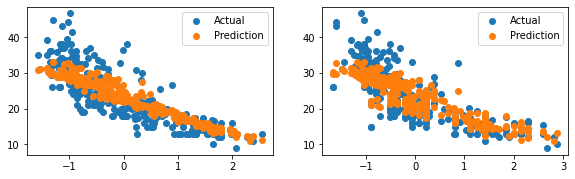



--------------------Training Set Metrics--------------------

R2-Score on Training set ---> 0.7565004321940874
Residual Sum of Squares (RSS) on Training set  ---> 4318.474942721264
Mean Squared Error (MSE) on Training set       ---> 14.491526653427059
Root Mean Squared Error (RMSE) on Training set ---> 3.8067737854286876

--------------------Testing Set Metrics--------------------

R2-Score on Testing set ---> 0.7714450361210365
Residual Sum of Squares (RSS) on Training set  ---> 887.6267236186565
Mean Squared Error (MSE) on Training set       ---> 11.835022981582087
Root Mean Squared Error (RMSE) on Training set ---> 3.4402068225009503

--------------------Residual Plots--------------------


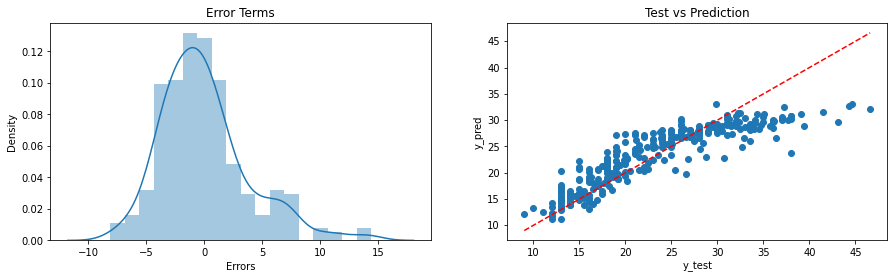

In [31]:
#Creating a Ridge Regression model

LLR = Lasso().fit(Train_X_std,Train_Y)
pred1 = LLR.predict(Train_X_std)
pred2 = LLR.predict(Test_X_std)

print('{}{}\033[1m Evaluating Lasso Regression Model \033[0m{}{}\n'.format('<'*3,'-'*35 ,'-'*35,'>'*3))
print('The Coeffecient of the Regresion Model was found to be ',MLR.coef_)
print('The Intercept of the Regresion Model was found to be ',MLR.intercept_)

Evaluate(2, pred1, pred2)

---

## 6d. Elastic-Net Regression

<img src="en.png" style="width: 500px;float: left;"/>

<<<----------------------------------- Evaluating Elastic-Net Regression Model ----------------------------------->>>

The Coeffecient of the Regresion Model was found to be  [ 0.37392838 -1.60991106 -4.23465249 -0.20323733  0.46219093  0.82410016
  3.52035285  0.82870138  2.12435476  3.40883424  0.31857547 -0.00832717
 -0.1305993   0.38329303  0.25287433  0.44466142  0.86632505  0.88266555
  1.16851361  2.31850714  1.70934819  2.0094862 ]
The Intercept of the Regresion Model was found to be  23.537919463087253


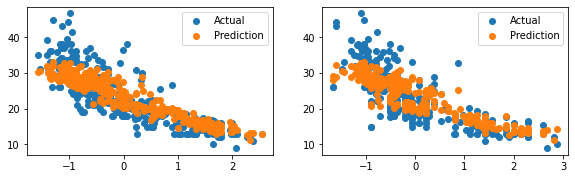



--------------------Training Set Metrics--------------------

R2-Score on Training set ---> 0.7764515564748133
Residual Sum of Squares (RSS) on Training set  ---> 3964.6409254300793
Mean Squared Error (MSE) on Training set       ---> 13.304164179295569
Root Mean Squared Error (RMSE) on Training set ---> 3.6474873789083313

--------------------Testing Set Metrics--------------------

R2-Score on Testing set ---> 0.8018086490939083
Residual Sum of Squares (RSS) on Training set  ---> 769.7051793086067
Mean Squared Error (MSE) on Training set       ---> 10.262735724114757
Root Mean Squared Error (RMSE) on Training set ---> 3.2035504872117677

--------------------Residual Plots--------------------


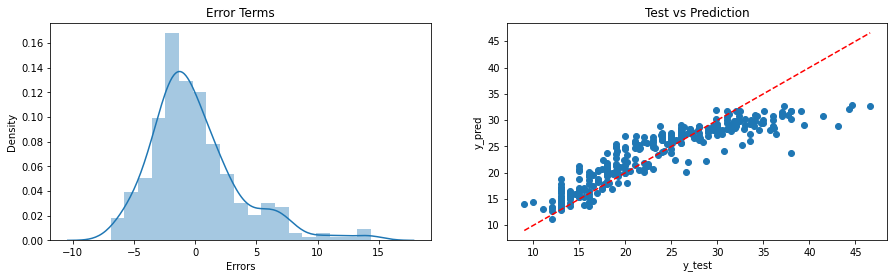

In [32]:
#Creating a ElasticNet Regression model

ENR = ElasticNet().fit(Train_X_std,Train_Y)
pred1 = ENR.predict(Train_X_std)
pred2 = ENR.predict(Test_X_std)

print('{}{}\033[1m Evaluating Elastic-Net Regression Model \033[0m{}{}\n'.format('<'*3,'-'*35 ,'-'*35,'>'*3))
print('The Coeffecient of the Regresion Model was found to be ',MLR.coef_)
print('The Intercept of the Regresion Model was found to be ',MLR.intercept_)

Evaluate(3, pred1, pred2)

---

## 6e. Polynomial Regression Model

<img src="pn.png" style="width: 500px;float: left;"/>

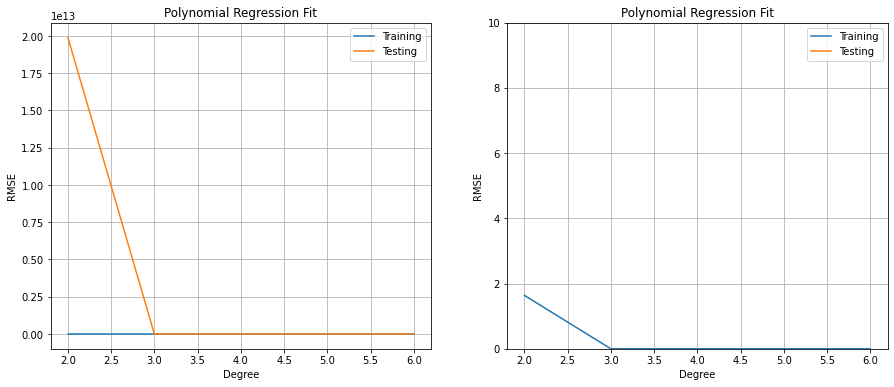

In [33]:
#Checking polynomial regression performance on various degrees

Trr=[]; Tss=[]
n_degree=7

for i in range(2,n_degree):
    #print(f'{i} Degree')
    poly_reg = PolynomialFeatures(degree=i)
    X_poly = poly_reg.fit_transform(Train_X_std)
    X_poly1 = poly_reg.fit_transform(Test_X_std)
    LR = LinearRegression()
    LR.fit(X_poly, Train_Y)
    
    pred1 = LR.predict(X_poly)
    Trr.append(np.sqrt(mean_squared_error(Train_Y, pred1)))
    
    pred2 = LR.predict(X_poly1)
    Tss.append(np.sqrt(mean_squared_error(Test_Y, pred2)))

plt.figure(figsize=[15,6])
plt.subplot(1,2,1)
plt.plot(range(2,n_degree),Trr, label='Training')
plt.plot(range(2,n_degree),Tss, label='Testing')
#plt.plot([1,4],[1,4],'b--')
plt.title('Polynomial Regression Fit')
#plt.ylim([0,5])
plt.xlabel('Degree')
plt.ylabel('RMSE')
plt.grid()
plt.legend()
#plt.xticks()

plt.subplot(1,2,2)
plt.plot(range(2,n_degree),Trr, label='Training')
plt.plot(range(2,n_degree),Tss, label='Testing')
plt.title('Polynomial Regression Fit')
plt.ylim([0,10])
plt.xlabel('Degree')
plt.ylabel('RMSE')
plt.grid()
plt.legend()
#plt.xticks()
plt.show()

**Inference:** We can choose 5th order polynomial regression as it gives the optimal training & testing scores...

<<<----------------------------------- Evaluating Polynomial Regression Model ----------------------------------->>>

The Coeffecient of the Regresion Model was found to be  [ 0.37392838 -1.60991106 -4.23465249 -0.20323733  0.46219093  0.82410016
  3.52035285  0.82870138  2.12435476  3.40883424  0.31857547 -0.00832717
 -0.1305993   0.38329303  0.25287433  0.44466142  0.86632505  0.88266555
  1.16851361  2.31850714  1.70934819  2.0094862 ]
The Intercept of the Regresion Model was found to be  23.537919463087253


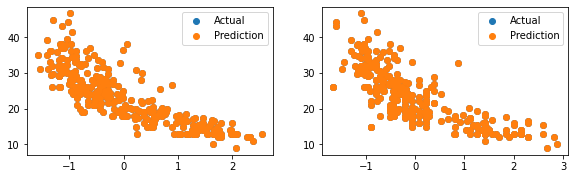



--------------------Training Set Metrics--------------------

R2-Score on Training set ---> 1.0
Residual Sum of Squares (RSS) on Training set  ---> 0.0
Mean Squared Error (MSE) on Training set       ---> 0.0
Root Mean Squared Error (RMSE) on Training set ---> 1.69180494e-12

--------------------Testing Set Metrics--------------------

R2-Score on Testing set ---> -2.8049524424547263
Residual Sum of Squares (RSS) on Training set  ---> 14777.090869964488
Mean Squared Error (MSE) on Training set       ---> 197.02787826619317
Root Mean Squared Error (RMSE) on Training set ---> 14.036661934598026

--------------------Residual Plots--------------------


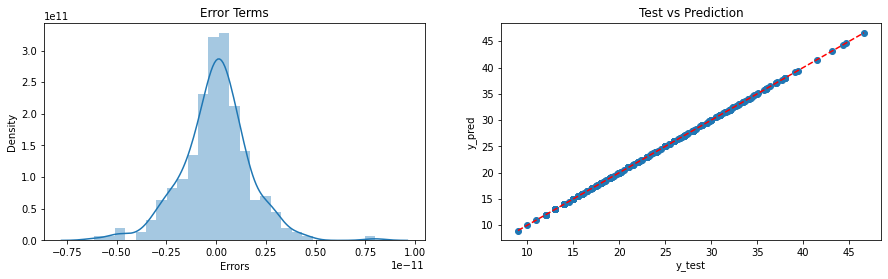

In [34]:
#Using the 5th Order Polynomial Regression model (degree=3)

poly_reg = PolynomialFeatures(degree=5)
X_poly = poly_reg.fit_transform(Train_X_std)
X_poly1 = poly_reg.fit_transform(Test_X_std)
PR = LinearRegression()
PR.fit(X_poly, Train_Y)

pred1 = PR.predict(X_poly)
pred2 = PR.predict(X_poly1)

print('{}{}\033[1m Evaluating Polynomial Regression Model \033[0m{}{}\n'.format('<'*3,'-'*35 ,'-'*35,'>'*3))
print('The Coeffecient of the Regresion Model was found to be ',MLR.coef_)
print('The Intercept of the Regresion Model was found to be ',MLR.intercept_)

Evaluate(4, pred1, pred2)

---

### 6f. Comparing the Evaluation Metics of the Models

In [35]:
# Regression Models Results Evaluation

EMC = Model_Evaluation_Comparison_Matrix.copy()
EMC.index = ['Multiple Linear Regression (MLR)','Ridge Linear Regression (RLR)','Lasso Linear Regression (LLR)','Elastic-Net Regression (ENR)','Polynomial Regression (PNR)']
EMC

,Train-R2,Test-R2,Train-RSS,Test-RSS,Train-MSE,Test-MSE,Train-RMSE,Test-RMSE
Multiple Linear Regression (MLR),0.871179,0.887136,2284.649400,438.325386,7.666609,5.844338,2.768864e+00,2.417507
Ridge Linear Regression (RLR),0.870853,0.887714,2290.434367,436.078919,7.686021,5.814386,2.772367e+00,2.411304
Lasso Linear Regression (LLR),0.756500,0.771445,4318.474943,887.626724,14.491527,11.835023,3.806774e+00,3.440207
Elastic-Net Regression (ENR),0.776452,0.801809,3964.640925,769.705179,13.304164,10.262736,3.647487e+00,3.203550
Polynomial Regression (PNR),1.000000,-2.804952,0.000000,14777.090870,0.000000,197.027878,1.691805e-12,14.036662


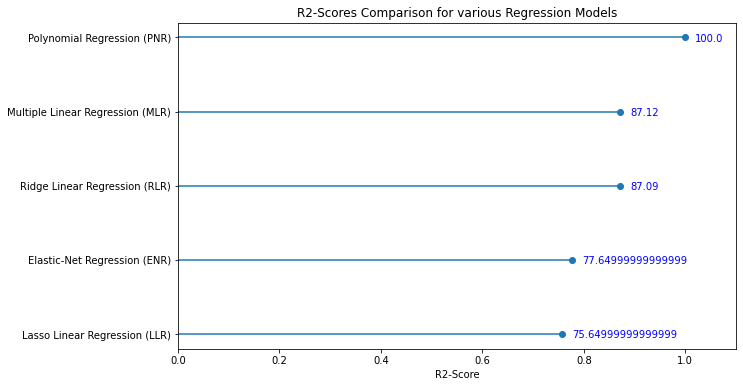

In [36]:
# R2-Scores Comparison for different Regression Models

R2 = round(EMC['Train-R2'].sort_values(ascending=True),4)
plt.hlines(y=R2.index, xmin=0, xmax=R2.values)
plt.plot(R2.values, R2.index,'o')
plt.title('R2-Scores Comparison for various Regression Models')
plt.xlabel('R2-Score')
#plt.ylabel('Regression Models')
for i, v in enumerate(R2):
    plt.text(v+0.02, i-0.05, str(v*100), color='blue')
plt.xlim([0,1.1])
plt.show()

**Inference:** From the above plot, it is clear that the polynomial regresion models have the highest explainability power  to understand the dataset.

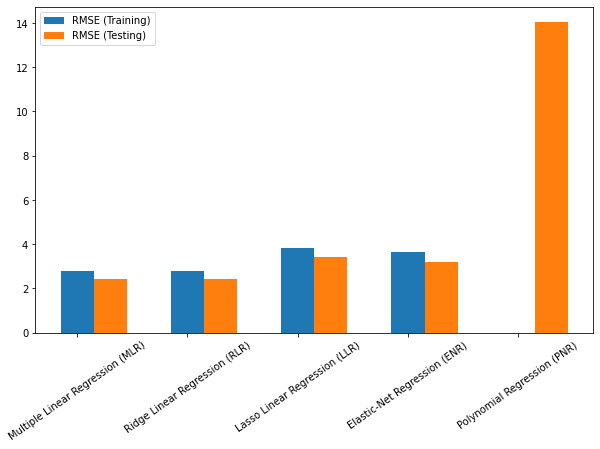

In [37]:
# Root Mean SquaredError Comparison for different Regression Models

cc = Model_Evaluation_Comparison_Matrix.columns.values
s=5
#baxes = brokenaxes(ylims=((0,4),(524,532)))
#baxes.bar(np.arange(s), Model_Evaluation_Comparison_Matrix[cc[-2]].values, width=0.3, label='RMSE (Training)')
#baxes.bar(np.arange(s)+0.3, Model_Evaluation_Comparison_Matrix[cc[-1]].values, width=0.3, label='RMSE (Testing)')
# for index, value in enumerate(Model_Evaluation_Comparison_Matrix[cc[-2]].values):
#     plt.text(round(value,2), index, str(round(value,2)))
# for index, value in enumerate(Model_Evaluation_Comparison_Matrix[cc[-1]].values):
#     plt.text(round(value,2), index, str(round(value,2)))
plt.bar(np.arange(5), Model_Evaluation_Comparison_Matrix[cc[6]].values, width=0.3, label='RMSE (Training)')
plt.bar(np.arange(5)+0.3, Model_Evaluation_Comparison_Matrix[cc[7]].values, width=0.3, label='RMSE (Testing)')
plt.xticks(np.arange(5),EMC.index, rotation =35)
plt.legend()
#plt.ylim([0,10])
plt.show()

**Inference:**\
Lesser the RMSE, better the model! Also, provided the model should have close proximity with the training & testing scores. For this problem, it is can be said that polynomial regressions clearly overfitting the current problem. Surprisingly simple MLR Model gave the best results. 

---

# <center> 7. Project Outcomes & Conclusions

### Here are some of the key outcomes of the project:
- The Dataset was quiet small with just 200 samples & after preprocessing 1% of the datasamples were dropped. 
- Visualising the distribution of data & their relationships, helped us to get some insights on the feature-set.
- The features had high multicollinearity, hence in Feature Extraction step, we shortlisted the appropriate features with VIF Technique.
- Testing multiple algorithms with default hyperparamters gave us some understanding for various models performance on this specific dataset.
- While, Polynomial Regression (Order-2) was the best choise, yet it is safe to use multiple regression algorithm, as their scores were quiet comparable & also they're more generalisable.

In [38]:
#<<<--------------------------------------------THE END------------------------------------------------>>>